
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [ ]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import math as mt

In [ ]:
# Wave function analitycal solution
def psi1(n,L,x):
    return np.sqrt(2/L)*np.sin(n*np.pi*x/L)

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2107/693635660.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.colorbar(label='Densidad de Probabilidad $|\psi|^2$')


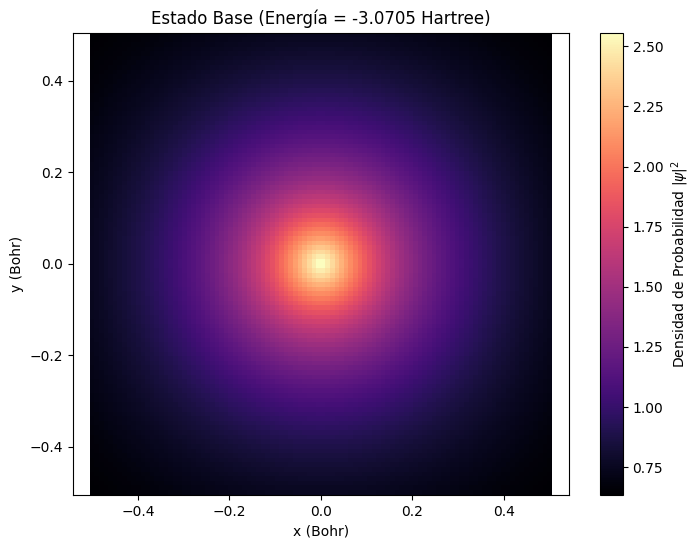

In [ ]:
# Parámetros del grid
grid_size = 100
L = 1.0              # Tamaño físico de la caja (en radios de Bohr) ; 1 radio de bohr
Delta = L / grid_size # Espaciamiento del grid
Niter = 20000
tolerancia = 1e-6     # Tolerancia para la energía
dtau = 0.05 * Delta**2 # Paso de "tiempo imaginario" (condición de estabilidad Courant)

# Crear el grid 2D centrado en el origen
x = np.linspace(-L/2, L/2, grid_size)
y = np.linspace(-L/2, L/2, grid_size)
X, Y = np.meshgrid(x, y)

# Distancia r al centro. Sumamos 1e-10 para evitar divergencia r=0 en el potencial
R = np.sqrt(X**2 + Y**2) + 1e-10
V_potencial = -1.0 / R  # Potencial de Coulomb en el plano 2D

# Wavefunction inicial de prueba (una campana gaussiana)
psi_initial = np.exp(-0.1 * (X**2 + Y**2))
# Normalización inicial (Dirichlet psi=0 en los bordes está implícito al iniciar cerca de 0)
psi_initial /= np.sqrt(np.sum(psi_initial**2) * Delta**2)

# Método de diferencias finitas en Tiempo Imaginario
def Schrodinger2D_FDM_ITP(psi_ini, V, Niter, tol, Delta, dtau):
    psi = psi_ini.copy()
    E_old = 0.0

    for i in range(Niter):
        # 1. Calcular el Laplaciano usando diferencias finitas (similar a tu promedio de 4 nodos)
        laplaciano = np.zeros_like(psi)
        laplaciano[1:-1, 1:-1] = (psi[2:, 1:-1] + psi[:-2, 1:-1] +
                                  psi[1:-1, 2:] + psi[1:-1, :-2] -
                                  4 * psi[1:-1, 1:-1]) / (Delta**2)

        # 2. Aplicar el Hamiltoniano: H*psi = (-1/2)*Laplaciano + V*psi
        H_psi = -0.5 * laplaciano + V * psi

        # 3. Propagación: psi_nueva = psi_vieja - dtau * (H * psi_vieja)
        psi = psi - dtau * H_psi

        # 4. Normalizar la función de onda (PASO CRUCIAL en tiempo imaginario)
        norm = np.sqrt(np.sum(psi**2) * Delta**2)
        psi = psi / norm

        # 5. Calcular la energía de expectación E = <psi|H|psi> cada 100 iteraciones
        if i % 100 == 0:
            H_psi_actual = -0.5 * laplaciano + V * psi
            E_current = np.sum(psi * H_psi_actual) * Delta**2

            # Criterio de parada basado en la convergencia de la energía
            if np.abs(E_current - E_old) < tol:
                print(f"Convergencia alcanzada en la iteración {i}.")
                print(f"Energía del estado base: {E_current:.4f} Hartree")
                break
            E_old = E_current

    return psi, E_current

# Ejecutar el solver
psi_final, E_final = Schrodinger2D_FDM_ITP(psi_initial, V_potencial, Niter, tolerancia, Delta, dtau)

# Visualizar la densidad de probabilidad |psi|^2
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, psi_final**2, shading='auto', cmap='magma')
plt.colorbar(label='Densidad de Probabilidad $|\psi|^2$')
plt.title(f'Estado Base (Energía = {E_final:.4f} Hartree)')
plt.xlabel('x (Bohr)')
plt.ylabel('y (Bohr)')
plt.axis('equal')
plt.show()